Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [3]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\TE_Intergenic_With_Distances.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Expression_TE_DESeq.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\Clinical_Data_Xiang20.csv"

Histogram

     0       1       2                   3     4  5     6     7     8   \
0  chr1  200408  200714       TE_L1MB3_dup2  1294  +    L1  LINE  chr1   
1  chr1  894861  895173      TE_AluSp_dup21  2383  -   Alu  SINE  chr1   
2  chr1  895289  895508      TE_AluYf1_dup3  1843  -   Alu  SINE  chr1   
3  chr1  895543  895868  TE_HERVK9-int_dup2  2132  -  ERVK   LTR  chr1   
4  chr1  895869  896099  TE_HERVK9-int_dup3  1753  -  ERVK   LTR  chr1   

       9       10               11 12 13     14  
0  182695  184174         DDX11L17  .  +  16235  
1  874528  877234  ENSG00000283040  .  -  17628  
2  874528  877234  ENSG00000283040  .  -  18056  
3  874528  877234  ENSG00000283040  .  -  18310  
4  874528  877234  ENSG00000283040  .  -  18636  
     Start     End  Count
0      1.0   500.9   3319
1    500.9  1000.8   3080
2   1000.8  1500.7   2791
3   1500.7  2000.6   2511
4   2000.6  2500.5   2255
5   2500.5  3000.4   2052
6   3000.4  3500.3   1887
7   3500.3  4000.2   1689
8   4000.2  4500.1   

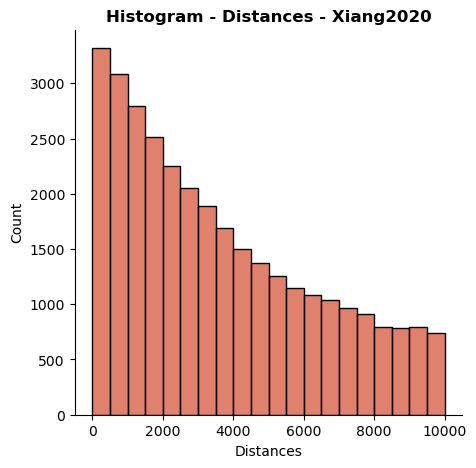

In [4]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
print(TEs_df.head())

TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Xiang2020', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA Intergenics - Data

In [5]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
print(TEs_df.head())
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize clinical data
clinical_df = clinical_df[['Sample_Name', 'Run', 'Condition']]

# Separate names and counts
TEs_names = expr_df.iloc[:, 0]
counts = expr_df.iloc[:, 1:]

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm + 1)

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample_Name', how = 'inner')
pca_df.head()

  TE_Chr  TE_Start  TE_End             TE_Name  TE_Score TE_Strand  \
0   chr1    200408  200714       TE_L1MB3_dup2      1294         +   
1   chr1    894861  895173      TE_AluSp_dup21      2383         -   
2   chr1    895289  895508      TE_AluYf1_dup3      1843         -   
3   chr1    895543  895868  TE_HERVK9-int_dup2      2132         -   
4   chr1    895869  896099  TE_HERVK9-int_dup3      1753         -   

  TE_Class-id TE_Family_id Gene_Chr  Gene_Start  Gene_End        Gene_Name  \
0          L1         LINE     chr1      182695    184174         DDX11L17   
1         Alu         SINE     chr1      874528    877234  ENSG00000283040   
2         Alu         SINE     chr1      874528    877234  ENSG00000283040   
3        ERVK          LTR     chr1      874528    877234  ENSG00000283040   
4        ERVK          LTR     chr1      874528    877234  ENSG00000283040   

  Gene_Score Gene_Strand  Distances  
0          .           +      16235  
1          .           -      1762

,Sample_Name,PC1,PC2,Run,Condition
0,Mut_D0,-235.621893,-122.519510,SRR7551512,MECP2_mutant
1,Mut_D10,-41.403945,154.596217,SRR7551514,MECP2_mutant
2,Mut_D18,-30.016090,122.728976,SRR7551516,MECP2_mutant
3,Mut_D32,100.567975,-47.870503,SRR7551518,MECP2_mutant
4,Mut_D46,102.188747,-101.106072,SRR7551520,MECP2_mutant


PCA - Graph

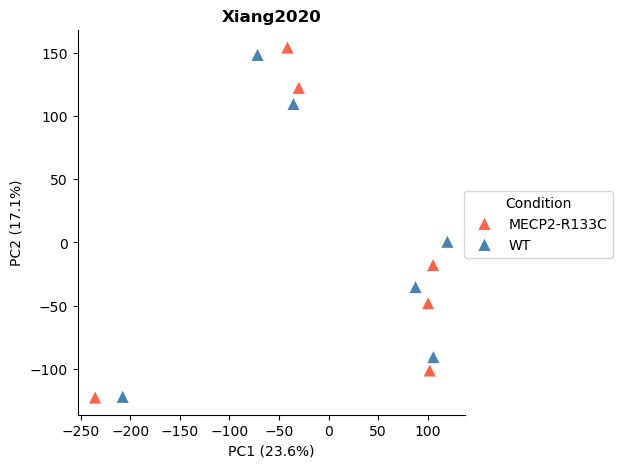

In [8]:
fig, ax = plt.subplots(figsize = (5 ,5))

palette_pca = {
    'MECP2-R133C' : 'tomato',
    'WT' : 'steelblue'
}

pca_df['Condition'] = pca_df['Condition'].replace({'MECP2_mutant' : 'MECP2-R133C'})
sns.scatterplot(pca_df, x = 'PC1', y = 'PC2', hue = 'Condition', palette = palette_pca, s = 100, marker = '^')

# Labels
ax.set_title('Xiang2020', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()